<a href="https://colab.research.google.com/github/aldynugraha17/IMW26-AAA/blob/main/azarya/Tutorial_PySNE_IMW26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PySNE Tutorial
## Finding All Solutions with *Spiral Optimization Algorithm* (SPO) + Clustering

PySNE is a Python library for finding all solutions of:
1. Systems of Nonlinear Equations (SNE),
2. Diophantine Equations (integer solutions), and
3. All optima of multimodal functions,

using the *Spiral Dynamics Optimization Algorithm* with clustering technique.

References:
- Sidarto, K. A. & Kania, A. (2015). *Finding all solutions of systems of nonlinear equations using spiral dynamics inspired optimization with clustering.* JACIII, 19(5).
- Sidarto, K. A., Kania, A., & Sumarti, N. (2017). *Finding multiple solutions of multimodal optimization using spiral optimization algorithm with clustering.* MENDEL, 23(1).
- Tamura, K. & Yasuda, K. (2011). *Spiral Dynamics Inspired Optimization.* JACIII, 15(8).

Tutorial roadmap:
1. Installation (development mode)
2. Spiral Optimization (SPO) — single-objective optimization
3. Finding SNE roots via transformation — still a single solution
4. Clustering — finding all roots
5. Diophantine equations (integer solutions)
6. Multimodal optimization — all optima

## 1. Installation

PySNE is still under development and has not yet been published on PyPI, so installation is done directly from the GitHub repository (`eksperimen` branch):

In [ ]:
# Install from GitHub (development mode).
!pip install git+https://github.com/p2ms-optimization/pysne.git@eksperimen

  Cloning https://github.com/p2ms-optimization/pysne.git (to revision eksperimen) to /tmp/pip-req-build-h0nuihnn
  Running command git clone --filter=blob:none --quiet https://github.com/p2ms-optimization/pysne.git /tmp/pip-req-build-h0nuihnn
  Running command git checkout -b eksperimen --track origin/eksperimen
  Switched to a new branch 'eksperimen'
  Branch 'eksperimen' set up to track remote branch 'eksperimen' from 'origin'.
  Resolved https://github.com/p2ms-optimization/pysne.git to commit 68cb5d4eec378f39b1910000a505bf2769d56e2c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2. Spiral Optimization (SPO) — single-objective optimization

Before diving into finding all solutions, let’s first understand the core engine: `spiral_dynamics_optimization`.

SPO moves $m$ search points in a spiral towards the current best point $x^*$ using the update rule:

$$x_i(k+1) = S_n(r, \theta)\, x_i(k) - \big(S_n(r, \theta) - I_n\big)\, x^*(k)$$

where $S_n = r\,R_n(\theta)$ and $R_n$ is a rotation matrix. The key parameters are:

| Parameter | Meaning | Reference value (Tamura & Yasuda, 2011) |
|---|---|---|
| `m` | number of search points | 20–250 |
| `r` | spiral contraction rate (0 < r < 1) | 0.95 |
| `theta` | rotation angle | $\pi/4$ |
| `k_max` | maximum number of iterations | 100–300 |

As an example, let’s minimize the 2D Rastrigin function — a multimodal function with many local minima, where the global minimum is at $x = (0,0)$ with $f = 0$:

In [ ]:
from pysne.optimizers.sdoa.engine import spiral_dynamics_optimization
import numpy as np

def rastrigin(x):
    """Rastrigin n-dimension."""
    x = np.atleast_2d(x)
    val = 10 * x.shape[1] + np.sum(x**2 - 10 * np.cos(2 * np.pi * x), axis=1)
    return val if val.size > 1 else val[0]

domain = [(-3, 10), (-3, 10)]
params = {'m': 100, 'r': 0.95, 'theta': np.pi / 4, 'k_max': 300}

x_star, history = spiral_dynamics_optimization(
    rastrigin, domain, params,
    minimization=True,       # we are looking for the MINIMUM
    return_history=True
)

print("x* =", np.round(x_star, 8))
print("f(x*) =", history[-1])

x* = [-5.e-08  5.e-08]
f(x*) = 1.1262102361797588e-12


### 2.1 Experiment: changing parameters

Spiral behavior is strongly influenced by the combination $(r, \theta)$: $r$ close to 1 slows contraction (longer exploration), $\theta$ controls how much the search path “spirals”. Let’s compare several combinations:

In [ ]:
results = []
for r in [0.90, 0.95, 0.99]:
    for theta in [np.pi/6, np.pi/4, np.pi/2]:
        p = {'m': 100, 'r': r, 'theta': theta, 'k_max': 300}
        xs, h = spiral_dynamics_optimization(
            rastrigin, domain, p, minimization=True, return_history=True)
        results.append({'r': r, 'theta': f"{theta/np.pi:.3f}π",
                      'f_best': h[-1], 'x*': np.round(xs, 4)})

pd.DataFrame(results).sort_values('f_best').reset_index(drop=True)

,r,theta,f_best,x*
0,0.90,0.167π,0.000000e+00,"[0.0, 0.0]"
1,0.90,0.250π,0.000000e+00,"[-0.0, 0.0]"
2,0.90,0.500π,0.000000e+00,"[0.0, 0.0]"
3,0.95,0.500π,6.110668e-13,"[-0.0, -0.0]"
4,0.95,0.250π,1.126210e-12,"[-0.0, 0.0]"
5,0.95,0.167π,2.238210e-12,"[-0.0, -0.0]"
6,0.99,0.500π,4.011867e-02,"[-0.0101, -0.0101]"
7,0.99,0.167π,4.154095e-02,"[-0.0102, -0.0102]"
8,0.99,0.250π,8.074878e-02,"[-0.0191, -0.0065]"


## 3. Finding Roots of Systems of Nonlinear Equations — Transformation

The problem of finding roots $f_i(x) = 0,\ i = 1, \dots, m$ is transformed into a maximization problem:

$$F(x) = \frac{1}{1 + \sum_i |f_i(x)|}$$

The key property: $0 < F(x) \le 1$, and $F(x) = 1$ if and only if $x$ is a root of the system. Thus finding roots = finding points where $F(x) = 1$.

We use the system from Sidarto & Kania (2015), Problem 1:

$$\begin{cases} e^{x_1 - x_2} - \sin(x_1 + x_2) = 0 \\ x_1^2 x_2^2 - \cos(x_1 + x_2) = 0 \end{cases}$$

In [ ]:
from pysne.utils import objective_function

equations = [
    lambda x: np.exp(x[0] - x[1]) - np.sin(x[0] + x[1]),
    lambda x: x[0]**2 * x[1]**2 - np.cos(x[0] + x[1]),
]

# Fitness: F(x) = 1 / (1 + sum |f_i(x)|), maximized
fitness = lambda x: objective_function(x, equations)

domain_sne = [(-10, 10), (-10, 10)]
params = {'m': 200, 'r': 0.95, 'theta': np.pi / 4, 'k_max': 300}

root, hist = spiral_dynamics_optimization(
    fitness, domain_sne, params,
    minimization=False,      # MAXIMIZATION (default), F -> 1
    return_history=True
)

print("Root candidate:", np.round(root, 6))
print("F(root)       :", hist[-1])
print("Residual      :", [float(abs(f(root))) for f in equations])

Root candidate: [-6.117113 -0.163475]
F(root)       : 0.9999995150279988
Residual      : [1.4158213848189383e-07, 3.4339009791217734e-07]


## TAMBAHHKAN GAMBAR KETEMU SATU SOLUSI

### 3.1 Different parameters → different root found

Since only one root is returned per run, which root is found depends on initialization and parameters. Run the following cell several times with different `theta` values:

## DIJALANKAN BEBERAPA KALI DENGAN RANDOM INITIALIZATION

In [ ]:
for theta in [np.pi/6, np.pi/4, np.pi/3, np.pi/2]:
    p = {'m': 200, 'r': 0.95, 'theta': theta, 'k_max': 300}
    a, h = spiral_dynamics_optimization(fitness, domain_sne, p, return_history=True)
    print(f"theta = {theta/np.pi:.3f}π  ->  root = {np.round(a, 5)},  F = {h[-1]:.8f}")

theta = 0.167π  ->  root = [0.66712 0.6901 ],  F = 0.99999985
theta = 0.250π  ->  root = [-6.11711 -0.16348],  F = 0.99999952
theta = 0.333π  ->  root = [-0.93212  1.06787],  F = 0.99999989
theta = 0.500π  ->  root = [-6.11711 -0.16348],  F = 0.99999979


The problem is clear: this system has 6 roots in the given domain, but each run captures only one — and we don’t know which roots are "missing". This is where clustering technique comes in.

## 4. Clustering — Finding All Roots

The `solve_system` pipeline operates in three phases (Sidarto & Kania, 2015):

1. Iterative clustering — scatter `m_cluster` points (Sobol), run a few spiral steps, detect promising regions as *clusters*;
2. SPO per cluster — run full SDOA within each cluster (one root per cluster);
3. Selection & validation — discard duplicates (distance < `delta`) and candidates with residual > `epsilon`.

Parameter dictionary:

| Group | Parameter | Meaning |
|---|---|---|
| Clustering | `m_cluster` | number of initial points |
| | `k_cluster` | spiral iterations per clustering cycle |
| | `r_cl`, `theta_cl` | spiral parameters for the clustering phase |
| | `gamma` | fitness threshold for retained points |
| SPO | `spo_m`, `spo_k_max`, `r`, `theta` | SDOA parameters per cluster |
| Selection | `epsilon` | residual tolerance for valid roots |
| | `delta` | minimum distance between unique roots |

PySNE provides ready-to-use benchmark problems with pre-calibrated parameters:

In [ ]:
from pysne.problems.benchmarks_sne import get_problem_set
from pysne.solver import solve_system
from pysne.problems.base import SNEProblem

class problem_1(SNEProblem):
    @property
    def name(self):
        return "Problem 1 Benchmark System Non-linear Equation"

    def get_equations(self):
        equations = [
            lambda x: np.exp(x[0] - x[1]) - np.sin(x[0] + x[1]),
            lambda x: x[0]**2 * x[1]**2 - np.cos(x[0] + x[1])
        ]
        return equations

    def get_info(self):
        domain = [(-10, 10), (-10, 10)]
        params = {
            'm_cluster': 250,
            'r_cl': 0.95, # r
            'theta_cl': np.pi/4, # theta
            'k_cluster': 10,
            'epsilon': 1e-7,
            'delta': 0.01,
            'sdoa_m': 250,
            'sdoa_k_max': 270,
            'r': 0.95, # sdoa_r
            'theta': np.pi/4, # sdoa_theta
            'gamma': 0.2
        }
        return domain, params

# problems_sne = get_problem_set()      # dict {1: factory, 2: factory, ...}
# prob = problems_sne[1]()              # Problem 1 (same system as Section 3)
prob_sne = problem_1()

domain, params = prob_sne.get_info()      # domain & pre-calibrated parameters
print("Problem :", prob_sne.name)
print("Domain  :", domain)
print("Expected roots:", params['expected_roots'])

result = solve_system(prob_sne, params, verbose=True)

Problem : Problem 1 Benchmark System Non-linear Equation
Domain  : [(-10, 10), (-10, 10)]
Expected roots: 6


/usr/local/lib/python3.12/dist-packages/pysne/initialization/sampling.py:36: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  unit_points = sampler.random(n=num_points)


Search completed in 11.132 seconds.
Found 21 clusters and 6 valid roots.


In [ ]:
# Table of roots + individual residuals
all_roots = result['roots']
df = pd.DataFrame(all_roots, columns=['x1', 'x2'])
df['residual_total'] = [
    sum(abs(f(x)) for f in prob.get_equations()) for x in all_roots
]
df.round(8)

,x1,x2,residual_total
0,-6.117113,-0.163476,4.000000e-08
1,-0.932122,1.067874,5.000000e-08
2,0.667121,0.690103,7.000000e-08
3,-0.155283,6.439836,8.000000e-08
4,0.163333,6.122434,8.000000e-08
5,-6.437163,0.155348,9.000000e-08


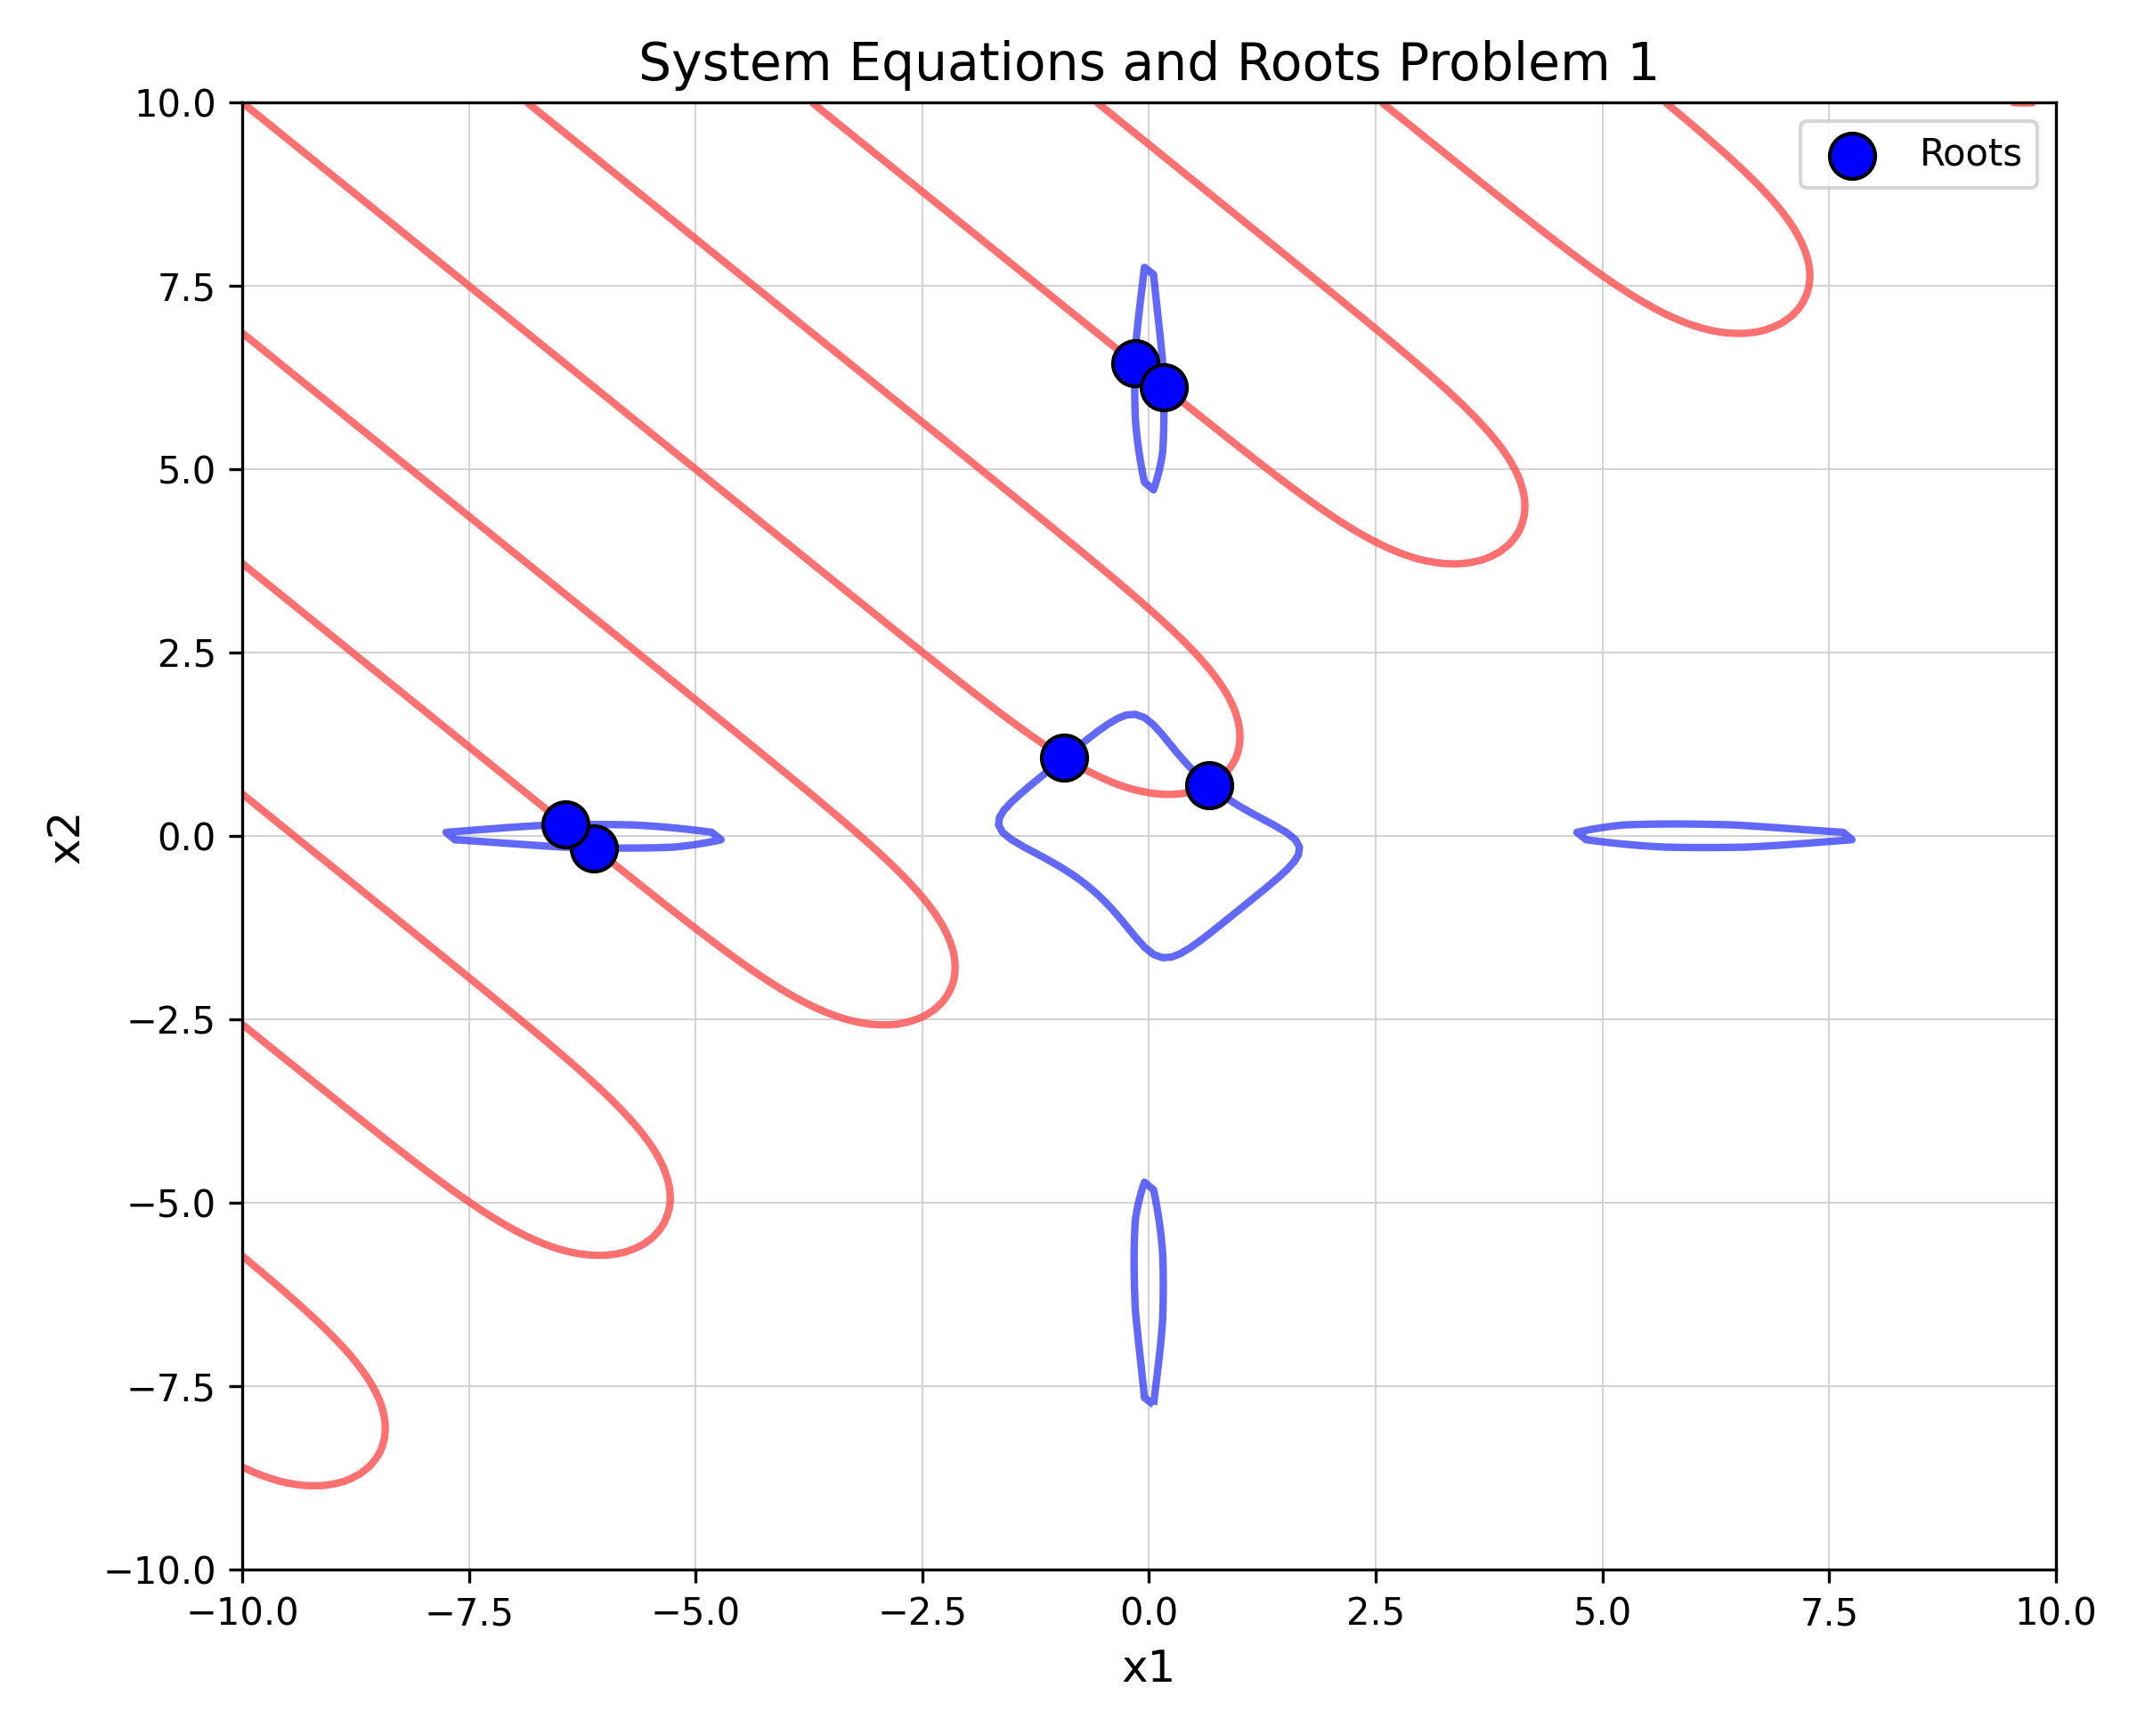

### 4.1 Defining your own SNE problem

Simply subclass `SNEProblem` and implement three things: `name`, `get_equations()`, and `get_info()`:

In [ ]:
from pysne.problems.base import SNEProblem

class MyProblem(SNEProblem):
    @property
    def name(self):
        return "Example: circle & hyperbola"

    def get_equations(self):
        # x^2 + y^2 = 4  and  xy = 1  ->  4 roots
        return [
            lambda x: x[0]**2 + x[1]**2 - 4,
            lambda x: x[0] * x[1] - 1,
        ]

    def get_info(self):
        domain = [(-3, 3), (-3, 3)]
        params = {
            'm_cluster': 512, 'k_cluster': 10,
            'r_cl': 0.95, 'theta_cl': np.pi / 4,
            'gamma': 0.5,                    # recommended for SNE
            'sdoa_m': 128, 'sdoa_k_max': 400,
            'r': 0.95, 'theta': np.pi / 4,
            'epsilon': 1e-7, 'delta': 0.01,
            'expected_roots': 4,
        }
        return domain, params

my_prob = MyProblem()
domain, params = my_prob.get_info()
my_result = solve_system(my_prob, params, verbose=True)
print(np.round(my_result['roots'], 6))

Search completed in 3.955 seconds.
Found 29 clusters and 4 valid roots.
[[-0.517638 -1.931852]
 [ 1.931852  0.517638]
 [-1.931852 -0.517638]
 [ 0.517638  1.931852]]


In [ ]:
import numpy as np
from pysne.problems.base import SNEProblem
from pysne.solver import solve_system

class SistemSaya(SNEProblem):
    @property
    def name(self):
        return "Custom equation system example"

    def get_equations(self):
        return [
            lambda x: x[0]**2 + x[1]**2 - 4,
            lambda x: x[0] - x[1]
        ]

    def get_info(self):
        domain = [(-5, 5), (-5, 5)]
        params = {
            'm_cluster': 512, 'k_cluster': 10, 'gamma': 0.5,
            'sdoa_m': 128, 'sdoa_k_max': 400,
            'r': 0.95, 'theta': np.pi/4,
            'epsilon': 1e-7, 'delta': 0.01
        }
        return domain, params

# Instansiasi dan eksekusi -- API pemanggilan identik dengan Skenario 1
prob = SistemSaya()
hasil = solve_system(prob, prob.get_info()[1], verbose=True)
print(hasil['roots'])

Search completed in 1.800 seconds.
Found 13 clusters and 2 valid roots.
[[ 1.41421356  1.41421357]
 [-1.41421357 -1.41421354]]


## 5. Diophantine Equations — Integer Solutions

For Diophantine equations, PySNE works in a continuous domain constructed from the integer domain (integer bounds ± 0.5), and each evaluation rounds candidates to the nearest integer. A classic example:

$$15x + 11y = 12, \qquad x, y \in [-50, 50] \cap \mathbb{Z}$$

which has 7 integer solutions in that domain — and completes in less than one second:

## Multimodal Optimization — All Optima

For multimodal functions, the goal is to find all optima of a multimodal function (not just the global optimum). The key difference from SNE: the `gamma` threshold is relative — a point is retained if $F(x_i) > \gamma \cdot F(x^*)$.

Example: Six-Hump Camel Back — by default the solver searches for maxima; to find minima, wrap the problem with `MinimizedProblem`:

In [ ]:
from pysne.problems.benchmarks_multimodal import get_multimodal_problems
from pysne.solver import solve_system
from pysne.problems.base import MultimodalProblem, MinimizedProblem

# 1. Pilih problem bawaan (contoh: Six-Hump Camel Back)
# problems = get_multimodal_problems()
# prob = problems[2]()

class Problem2(MultimodalProblem):
    @property
    def name(self):
        return "Problem 2: Six Hump Camel Back Function"

    def g_func(self, x):
        x = np.asarray(x)
        x1 = x[0] if x.ndim == 1 else x[:, 0]
        x2 = x[1] if x.ndim == 1 else x[:, 1]
        term1 = (4 - 2.1 * x1**2 + (x1**4) / 3) * x1**2
        term2 = x1 * x2
        term3 = (-4 + 4 * x2**2) * x2**2
        return (term1 + term2 + term3)

    def get_info(self):
        domain = [(-1.9, 1.9), (-1.1, 1.1)]
        params = {
            'm_cluster': 300,
            'r_cl': 0.95,
            'theta_cl': np.pi/4,
            'k_cluster': 5,
            'epsilon': 1e-5,
            'delta': 0.1,
            'sdoa_m': 50,
            'sdoa_k_max': 250,
            'r': 0.95,
            'theta': np.pi/4,
            'gamma': -float('inf'),
            'num_check_points': 2

        }
        return domain, params

prob_mm = Problem2()

# 2. Ambil domain & parameter default yang sudah dikalibrasi
domain, params = prob_mm.get_info()

# 3. Jalankan solver -> mencari titik MAKSIMUM
hasil_max = solve_system(prob_mm, params, verbose=True)
print(hasil_max['optimals'])        # array koordinat solusi
print(hasil_max['time_elapsed']) # waktu eksekusi (detik)

print(f"Maksimum ditemukan: {len(hasil_max['optimals'])} titik")

/usr/local/lib/python3.12/dist-packages/pysne/initialization/sampling.py:36: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  unit_points = sampler.random(n=num_points)


Search completed in 1.475 seconds.
Found 93 clusters and 2 valid optimal solutions.
[[ 1.23022988  0.16233459]
 [-1.23022988 -0.16233459]]
1.4748964309692383
Maksimum ditemukan: 2 titik


In [ ]:
from pysne.problems.base import MinimizedProblem

# Membungkus problem yang sama untuk pencarian titik minimum
prob_mm_min = MinimizedProblem(prob_mm)
hasil_min = solve_system(prob_mm_min, params, verbose=True)

print(hasil_min['optimals'])        # array koordinat solusi
print(hasil_min['time_elapsed']) # waktu eksekusi (detik)

print(f"Minimum ditemukan : {len(hasil_min['optimals'])} titik")

/usr/local/lib/python3.12/dist-packages/pysne/initialization/sampling.py:36: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  unit_points = sampler.random(n=num_points)


Search completed in 1.367 seconds.
Found 109 clusters and 6 valid optimal solutions.
[[-0.08984201  0.7126564 ]
 [ 0.08984202 -0.7126564 ]
 [ 1.70360671 -0.79608357]
 [-1.70360672  0.79608356]
 [ 1.60710476  0.56865146]
 [-1.60710474 -0.56865145]]
1.366647481918335
Minimum ditemukan : 6 titik
